In [2]:
import os
print(os.getcwd())

C:\Users\tharm\Desktop\Data sets


In [4]:
import pandas as pd
import numpy as np
import re
import random
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import norm
from scipy import linalg as la

path = "C:\\Users\\tharm\\Desktop\\Data sets\\MIMIC-III\\" 

In [6]:
import warnings
warnings.filterwarnings('ignore') 


# Creating the main working dataset

## 1. Merging the required tables and columns from MIMIC-III demo database to create the target label 

### 1.1 SOFA score prediction

In [11]:
# Load & process CHARTEVENTS table(extract hourly vital sings for SOFA score redicrtion- MAP, FiO2, GCS)
# Load & process LABEVENTS table (extract hourly lab test results for SOFA score prediction - PaO2, Creatinine, Bilirubin, and platelets)
# Load INPUTEVENTS_MV table (extract, standardize, and aggregate vasopressor doses)
# Merge vital signs and laboratory test results into a single data set
# Define helpers to normalize FiO2 and detect whether the patient is on respiratory support
# Compute SOFA score for each required organ system separately and find the total SOFA score.

In [13]:
# Load CHARTEVENTS (vitals: MAP, FiO2, GCS)
chartevents = pd.read_csv(
    os.path.join(path, "CHARTEVENTS.csv"),
    usecols=["subject_id", "hadm_id", "icustay_id", "charttime", "itemid", "valuenum"],
    low_memory=False
)
chartevents = chartevents[chartevents["itemid"].isin([456, 52, 220052, 223900, 198, 3420, 223835])]
chartevents["charttime"] = pd.to_datetime(chartevents["charttime"])
chartevents["hour"] = chartevents["charttime"].dt.floor("H")

# Normalize FiO2 for itemid 3420 (convert from % to fraction)
chartevents.loc[chartevents["itemid"] == 3420, "valuenum"] /= 100.0

# Map itemid to label
chartevents["label"] = chartevents["itemid"].map({
    456: "MAP", 52: "MAP", 220052: "MAP",
    223900: "GCS", 198:"GCS",
    3420: "FiO2", 223835: "FiO2"
})
vitals = chartevents.pivot_table(
    index=["subject_id", "hadm_id", "icustay_id", "hour"],
    columns="label",
    values="valuenum",
    aggfunc="mean"
).reset_index()

In [15]:
# Load LABEVENTS (labs: PaO2, Creatinine, Bilirubin, Platelets)
labevents = pd.read_csv(
    os.path.join(path, "LABEVENTS.csv"),
    usecols=["subject_id", "hadm_id", "charttime", "itemid", "valuenum"],
    low_memory=False
)
labevents = labevents[labevents["itemid"].isin([50821, 50912, 50885, 51265])]
labevents["charttime"] = pd.to_datetime(labevents["charttime"])
labevents["hour"] = labevents["charttime"].dt.floor("H")

# Map itemid to label
labevents["label"] = labevents["itemid"].map({
    50821: "PaO2",
    50912: "Creatinine",
    50885: "Bilirubin",
    51265: "Platelets"
})
labs = labevents.pivot_table(
    index=["subject_id", "hadm_id", "hour"],
    columns="label",
    values="valuenum",
    aggfunc="mean"
).reset_index()


In [17]:
# Load INPUTEVENTS_MV and extract vasopressors
vaso_itemids = {
    221906: "norepinephrine",  
    221289: "epinephrine",    
    221662: "dopamine",        
    221653: "dobutamine"       
}

# Load relevant columns only
input_mv = pd.read_csv(
    os.path.join(path, "INPUTEVENTS_MV.csv"),
    usecols=["subject_id", "hadm_id", "icustay_id", "starttime", "itemid", "rate", "rateuom"],
    low_memory=False
)

# Filter for the 4 vasopressors only
vasopressors = input_mv[input_mv["itemid"].isin(vaso_itemids.keys())].copy()

# Map itemid to drug name
vasopressors["drug"] = vasopressors["itemid"].map(vaso_itemids)

# Parse time and assign hourly bin
vasopressors["starttime"] = pd.to_datetime(vasopressors["starttime"])
vasopressors["hour"] = vasopressors["starttime"].dt.floor("H")

# Pivot table to get the hourly rate for each drug
vaso_pivot = vasopressors.pivot_table(
    index=["subject_id", "hadm_id", "icustay_id", "hour"],
    columns="drug",
    values="rate",
    aggfunc="max"  # Use max dose observed in that hour
).reset_index()

vaso_pivot.head()

drug,subject_id,hadm_id,icustay_id,hour,dobutamine,dopamine,norepinephrine
0,40304,174997,261743,2163-11-21 18:00:00,NaN,1.100234,NaN
1,40310,186361,210989,2144-07-13 11:00:00,NaN,10.012087,0.502150
2,40310,186361,210989,2144-07-13 19:00:00,NaN,NaN,0.200976
3,40310,186361,210989,2144-07-13 21:00:00,NaN,NaN,0.150698
4,40310,186361,210989,2144-07-13 22:00:00,NaN,NaN,0.090503


In [19]:
# Merge vitals and labs without icustay_id
combined = pd.merge(
    vitals,
    labs,
    on=["subject_id", "hadm_id", "hour"],
    how="outer"
)

# Merge with vasopressors
combined = pd.merge(
    combined,
    vaso_pivot,
    on=["subject_id", "hadm_id", "icustay_id", "hour"],
    how="outer"
)

#Fill missing icustay_id from vitals 
combined = pd.merge(
    combined,
    vitals[["subject_id", "hadm_id", "hour", "icustay_id"]],
    on=["subject_id", "hadm_id", "hour"],
    how="left",
    suffixes=("", "_vital")
)

# Use icustay_id from vitals if it's missing
combined["icustay_id"] = combined["icustay_id"].combine_first(combined["icustay_id_vital"])
combined.drop(columns=["icustay_id_vital"], inplace=True)
              
combined = combined.sort_values(by=["subject_id", "icustay_id", "hour"]).reset_index(drop=True)
combined.head()

,subject_id,hadm_id,icustay_id,hour,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,Platelets,dobutamine,dopamine,norepinephrine
0,10006,142345.0,206504.0,2164-10-23 22:00:00,NaN,NaN,63.666698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10006,142345.0,206504.0,2164-10-23 23:00:00,NaN,15.0,63.666698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10006,142345.0,206504.0,2164-10-24 00:00:00,NaN,NaN,77.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10006,142345.0,206504.0,2164-10-24 01:00:00,NaN,NaN,68.666702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10006,142345.0,206504.0,2164-10-24 02:00:00,NaN,NaN,73.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# If True, high-flow nasal cannula counts as "support" for SOFA resp 3/4
nc_support = False

# Convert FiO2 column to decimal fraction (0–1) once
combined["FiO2"] = pd.to_numeric(combined["FiO2"], errors="coerce")
combined["FiO2"] = combined["FiO2"].apply(lambda x: x/100.0 if pd.notna(x) and x > 1.0 else x)

# Helpers
def nor_fio2(x):
    if pd.isna(x):
        return np.nan
    try:
        v = float(x)
    except Exception:
        return np.nan
    if v > 1.0:          
        v = v / 100.0
    return min(max(v, 0.21), 1.0)  # clamp to [0.21, 1.0]

def truthy(v):
    if isinstance(v, str):
        return v.strip().lower() in {"true","1","yes","y","on"}
    return bool(v)

def has_resp_support(row):
    # 1) explicit boolean/flag columns
    invasive_cols = ("mech_vent", "vent", "ventilation", "invasive_vent", "intubated", "resp_support")
    niv_cols      = ("niv", "nippv", "non_invasive_vent", "noninvasive_vent", "bipap", "cpap")
    hfnc_cols     = ("hfnc", "high_flow", "high_flow_nc", "high_flow_nasal_cannula")

    for c in invasive_cols + niv_cols + (hfnc_cols if nc_support else ()):
        if c in row and pd.notna(row[c]) and truthy(row[c]):
            return 1

    # 2) device description text fields
    text_cols = ("oxygen_device","o2_device","resp_device","vent_device","device")
    device_text = ""
    for c in text_cols:
        if c in row and pd.notna(row[c]):
            device_text = str(row[c]).lower()
            if device_text:
                break

    inv_kw  = ("invasive", "mechanical ventilation", "intub", "et tube", "ett")
    niv_kw  = ("niv", "nippv", "bi-pap", "bipap", "cpap")
    hfnc_kw = ("hfnc", "high flow", "high-flow", "high flow nasal", "optiflow")

    if device_text:
        if any(k in device_text for k in inv_kw):
            return 1
        if any(k in device_text for k in niv_kw):
            return 1
        if nc_support and any(k in device_text for k in hfnc_kw):
            return 1

    # 3) fallback: FiO2 suggests support if > 0.21
    fio2_frac = nor_fio2(row.get("FiO2", np.nan))
    return int(pd.notna(fio2_frac) and fio2_frac > 0.21)

In [23]:
# SOFA scores prediction for the organ systems 

# 1. Nervous system — GCS (0–4)
def sofa_gcs(gcs):
    if pd.isna(gcs): return np.nan
    g = float(gcs)
    if g >= 15: return 0
    if g >= 13: return 1
    if g >= 10: return 2
    if g >= 6:  return 3
    return 4

combined["SOFA_GCS"] = combined["GCS"].apply(sofa_gcs)

# 2. Respiratory — PaO2/FiO2 (with support requirement for scores 3/4)
def sofa_pf(row):
    pao2 = row.get("PaO2", np.nan)   
    fio2 = row.get("FiO2", np.nan)   
    if pd.isna(pao2) or pd.isna(fio2):
        return np.nan

    fio2_frac = nor_fio2(fio2)
    if pd.isna(fio2_frac) or fio2_frac <= 0:
        return np.nan

    pf = float(pao2) / fio2_frac
    support = has_resp_support(row)

    # SOFA thresholds
    # >=400:0, <400:1, <300:2, <200:3 (with support), <100:4 (with support)
    if pf >= 400: return 0
    if pf < 100:  return 4 if support else 2
    if pf < 200:  return 3 if support else 2
    if pf < 300:  return 2
    if pf < 400:  return 1
    return 0

combined["SOFA_PF"] = combined.apply(sofa_pf, axis=1)

# 3. Coagulation — Platelets
def sofa_plt(platelets):
    if pd.isna(platelets): return np.nan
    p = float(platelets)
    if p >= 150: return 0
    if p < 20:   return 4
    if p < 50:   return 3
    if p < 100:  return 2
    return 1

combined["SOFA_PLT"] = combined["Platelets"].apply(sofa_plt)

# 4. Liver — Bilirubin
def sofa_bil(bilirubin):
    if pd.isna(bilirubin): return np.nan
    b = float(bilirubin)
    if b < 1.2:  return 0
    if b < 2.0:  return 1
    if b < 6.0:  return 2
    if b < 12.0: return 3
    return 4

combined["SOFA_BIL"] = combined["Bilirubin"].apply(sofa_bil)

# 5. Renal — Creatinine OR urine output 
def sofa_cre(row):
    cr  = row.get("Creatinine", np.nan)
    u24 = row.get("UrineOutput_24h", np.nan) 
    # urine-output overrides when severe 
    if pd.notna(u24):
        try:
            u24v = float(u24)
        except Exception:
            u24v = np.nan
        if pd.notna(u24v):
            if u24v < 200: return 4
            if u24v < 500: return 3
    if pd.isna(cr): return np.nan
    c = float(cr)
    if c < 1.2: return 0
    if c < 2.0: return 1
    if c < 3.5: return 2
    if c < 5.0: return 3
    return 4

combined["SOFA_CRE"] = combined.apply(sofa_cre, axis=1)

# 6. Cardiovascular — MAP and vasopressors 
def sofa_cv(row):
    map = row.get("MAP", np.nan)

    # pressor doses (normalize upstream if needed)
    ne   = float(row.get("norepinephrine", 0) or 0)
    epi  = float(row.get("epinephrine", 0) or 0)
    dopa = float(row.get("dopamine", 0) or 0)
    dobu = float(row.get("dobutamine", 0) or 0)

    # pressor-based scoring
    if (ne > 0) or (epi > 0) or (dopa > 0) or (dobu > 0):
        # 4: dopamine >15 OR (epi > 0.1 or norepi > 0.1)
        if (dopa > 15) or (epi > 0.1) or (ne > 0.1):
            return 4
        # 3: dopamine >5 OR (0 < epi <= 0.1 or 0 < norepi <= 0.1)
        if (dopa > 5) or (0 < epi <= 0.1) or (0 < ne <= 0.1):
            return 3
        # 2: dopamine <= 5 OR dobutamine (any dose)
        return 2

    # no pressors: MAP-based
    if pd.isna(map):
        return np.nan
    return 0 if float(map) >= 70 else 1

combined["SOFA_CV"] = combined.apply(sofa_cv, axis=1)

# Total SOFA
required = ["SOFA_CV","SOFA_GCS","SOFA_PF","SOFA_PLT","SOFA_BIL","SOFA_CRE"]
combined["SOFA_TOTAL"] = combined[required].fillna(0).sum(axis=1)

combined.head()

,subject_id,hadm_id,icustay_id,hour,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,...,dobutamine,dopamine,norepinephrine,SOFA_GCS,SOFA_PF,SOFA_PLT,SOFA_BIL,SOFA_CRE,SOFA_CV,SOFA_TOTAL
0,10006,142345.0,206504.0,2164-10-23 22:00:00,NaN,NaN,63.666698,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,10006,142345.0,206504.0,2164-10-23 23:00:00,NaN,15.0,63.666698,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.0,1.0
2,10006,142345.0,206504.0,2164-10-24 00:00:00,NaN,NaN,77.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,10006,142345.0,206504.0,2164-10-24 01:00:00,NaN,NaN,68.666702,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,10006,142345.0,206504.0,2164-10-24 02:00:00,NaN,NaN,73.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


### 1.2 Suspected Infection Information

In [26]:
# Probe PRESCRIPTIONS and MICROBIOLOGY headers (select only required columns and date fields, then load dataframes)
# Identify antibiotic administrations (choose time column, filter by antibiotic keywords, exclude non-systemic routes)
# Identify culture events and match with antibiotics (apply Sepsis-3 timing rules: abx - culture ≤24h, culture - abx ≤72h)
# Select earliest antibiotic–culture pair per admission and create suspected infection flag

In [28]:
# Load prescription and microbiology data set using only required columns and parsing relevant data fields 

# Probe headers to build safe usecols/parse_dates
presc_probe = pd.read_csv(os.path.join(path, "PRESCRIPTIONS.csv"), nrows=0, low_memory=False)
micro_probe = pd.read_csv(os.path.join(path, "MICROBIOLOGYEVENTS.csv"), nrows=0, low_memory=False)

presc_wanted = [
    "subject_id","hadm_id",
    "drug","drug_name_generic","drug_name_poe",
    "route",
    "drug_starttime","drug_stoptime","enddate","startdate","starttime","stoptime"
]
presc_usecols   = [c for c in presc_wanted if c in presc_probe.columns]
presc_date_cols = [c for c in ["startdate","enddate","starttime","stoptime","drug_starttime","drug_stoptime"]
                   if c in presc_usecols]

micro_wanted = ["subject_id","hadm_id","charttime","spec_type_desc","org_name"]
micro_usecols   = [c for c in micro_wanted if c in micro_probe.columns]
micro_date_cols = [c for c in ["charttime"] if c in micro_usecols]

# Load with safe usecols 
prescriptions_df = pd.read_csv(
    os.path.join(path, "PRESCRIPTIONS.csv"),
    usecols=presc_usecols,
    parse_dates=presc_date_cols,
    low_memory=False
)
micro_df = pd.read_csv(
    os.path.join(path, "MICROBIOLOGYEVENTS.csv"),
    usecols=micro_usecols,
    parse_dates=micro_date_cols,
    low_memory=False
)

In [30]:
# Antibiotics extraction (time, keywords, route filters)
#Choose a usuable antibiotic time column
abx_time_col = next((c for c in ["startdate","starttime","drug_starttime","enddate","stoptime","drug_stoptime"]
                     if c in prescriptions_df.columns), None)
if abx_time_col is None:
    raise ValueError("No antibiotic time column found in PRESCRIPTIONS.")

presc = prescriptions_df.copy()
presc[abx_time_col] = pd.to_datetime(presc[abx_time_col], errors="coerce")

abx_keywords = [
    "amox","ampi","piperacillin","tazobactam","zosyn",
    "cef","ceph","ceftriaxone","ceftazidime","cefepime",
    "meropenem","imipenem","ertapenem","carbapenem",
    "vancomycin","linezolid","daptomycin","tigecycline",
    "aztreonam","metronidazole","clindamycin",
    "levofloxacin","ciprofloxacin","moxifloxacin","ofloxacin",
    "azithro","clarithro","erythro",
    "tmp smx","cotrimoxazole","trimethoprim","sulfamethoxazole",
    "gentamicin","tobramycin","amikacin",
    "colistin","polymyxin"
]

def exclude_route(r):
    if pd.isna(r): return False
    r = str(r).lower()
    return any(x in r for x in ["top","ophth","otic","inhal","neb","cream","oint","eye","ear","nas","vag"])

name_cols = [c for c in ["drug_name_generic","drug_name_poe","drug"] if c in presc.columns]
presc["name"] = presc[name_cols].astype(str).agg(" ".join, axis=1).str.lower()

mask = pd.Series(False, index=presc.index)
for kw in abx_keywords:
    mask |= presc["name"].str.contains(kw, na=False)

if "route" in presc.columns:
    mask &= ~presc["route"].apply(exclude_route)
mask &= presc[abx_time_col].notna()

abx = (presc.loc[mask, ["subject_id","hadm_id",abx_time_col,"route","drug","drug_name_generic","drug_name_poe"]]
             .rename(columns={abx_time_col:"abx_time","drug":"abx_drug"}))

In [32]:
#Prepare culture data and match with antibiotics using Sepsis-3 timing rules (abx - culture<=24h and culture - abx<=72h)
micro = micro_df.copy()
micro["culture_time"] = pd.to_datetime(micro["charttime"], errors="coerce")
cult = (micro[["subject_id","hadm_id","culture_time","spec_type_desc","org_name"]]
        .rename(columns={"spec_type_desc":"specimen"})
        .dropna(subset=["culture_time"]))

# Prep helpers & asof by hadm 
def prep(df, timecol):
    out = df.dropna(subset=["hadm_id", timecol]).copy()
    out["hadm_id"] = pd.to_numeric(out["hadm_id"], errors="coerce").astype("Int64")
    out[timecol] = pd.to_datetime(out[timecol], errors="coerce")
    out = out.dropna(subset=[timecol])
    return out.sort_values(["hadm_id", timecol])

abx_ready  = prep(abx,  "abx_time")
cult_ready = prep(cult, "culture_time")

def asof_by_hadm(left, right, left_on, right_on, tol, direction):
    out = []
    for hadm, L in left.groupby("hadm_id", sort=False):
        R = right[right["hadm_id"] == hadm]
        if L.empty or R.empty: 
            continue
        Ls = L.sort_values(left_on)
        Rs = R.sort_values(right_on)
        m = pd.merge_asof(Ls, Rs, left_on=left_on, right_on=right_on,
                          direction=direction, tolerance=tol)
        m["hadm_id"] = hadm
        out.append(m)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

# Build candidate pairs by the Sepsis-3 timing rule  
# Case A: abx - culture within 24h
caseA = asof_by_hadm(abx_ready, cult_ready, "abx_time", "culture_time",
                      tol=pd.Timedelta("24H"), direction="forward")
if not caseA.empty:
    caseA = caseA.dropna(subset=["culture_time"]).copy()
    caseA["pair_onset_time"] = caseA[["abx_time","culture_time"]].min(axis=1)  

# Case B: culture - abx within 72h
caseB = asof_by_hadm(cult_ready, abx_ready, "culture_time", "abx_time",
                      tol=pd.Timedelta("72H"), direction="forward")
if not caseB.empty:
    caseB = caseB.dropna(subset=["abx_time"]).copy()
    caseB["pair_onset_time"] = caseB[["abx_time","culture_time"]].min(axis=1) 

# Combine candidate pairs
pairs = pd.concat([caseA, caseB], ignore_index=True, sort=False) if (not caseA.empty or not caseB.empty) else pd.DataFrame()

In [34]:
# Reduce to one row per HADM and create infection flag 
cols_keep = [
    "subject_id","hadm_id","pair_onset_time",
    "abx_time","culture_time",
    "abx_drug","drug_name_generic","route","specimen","org_name"
]
if not pairs.empty:
    susp_infect_HADM = (
        pairs.sort_values(["hadm_id","pair_onset_time"])
             .groupby("hadm_id", as_index=False)
             .first()
    )
    susp_infect_HADM = susp_infect_HADM[[c for c in cols_keep if c in susp_infect_HADM.columns]]
    susp_infect_HADM = susp_infect_HADM.rename(columns={"pair_onset_time":"suspected_infection_time"})
else:
    susp_infect_HADM = pd.DataFrame(columns=[*cols_keep])
    susp_infect_HADM = susp_infect_HADM.rename(columns={"pair_onset_time":"suspected_infection_time"})

# Direct infection flag 
susp_infect_HADM["suspected_infection_flag"] = 1  
display(susp_infect_HADM.head())


,hadm_id,suspected_infection_time,abx_time,culture_time,abx_drug,drug_name_generic,route,specimen,org_name,suspected_infection_flag
0,100375,2129-05-02 00:00:00,2129-05-02,2129-05-02 00:21:00,Vancomycin HCl,Levofloxacin,IV,URINE,None,1
1,101361,2145-12-01 19:10:00,2145-12-02,2145-12-01 19:10:00,Meropenem,None,IV,BLOOD CULTURE,PSEUDOMONAS AERUGINOSA,1
2,102203,2127-07-29 00:00:00,2127-07-29,2127-07-29 04:00:00,CeftriaXONE,None,IV,BLOOD CULTURE,None,1
3,103379,2170-12-15 00:00:00,2170-12-15,2170-12-15 02:37:00,Vancomycin,MetRONIDAZOLE (FLagyl),IV,BLOOD CULTURE,ESCHERICHIA COLI,1
4,103770,2195-05-17 00:00:00,2195-05-17,2195-05-17 09:12:00,Ciprofloxacin IV,Ciprofloxacin HCl,IV,URINE,ENTEROBACTERIACEAE,1


### 1.3 Merging two conditions (1.1 & 1.2)

In [37]:
# Merge SOFA scores with suspected infection info using hadm_id/icustay_id as key
# Prepare infection table (clean times, ensure 0/1 flag, keep earliest event per admission)
# Compute ΔSOFA (max − min) per admission
# Merge infection info and ΔSOFA into final dataset
# Create Sepsis-3 label: infection present AND ΔSOFA ≥ 2

In [39]:
# Merge SOFA score + suspected infection information 
combined = combined.copy()
combined["SOFA_TOTAL"] = pd.to_numeric(combined.get("SOFA_TOTAL"), errors="coerce")

# Pick infection table
if "susp_infect_HADM" in globals() and isinstance(susp_infect_HADM, pd.DataFrame) and not susp_infect_HADM.empty:
    INF = susp_infect_HADM.copy()
elif "SUSPECTED_INFECTION" in globals() and isinstance(SUSPECTED_INFECTION, pd.DataFrame) and not SUSPECTED_INFECTION.empty:
    INF = SUSPECTED_INFECTION.copy()
else:
    INF = pd.DataFrame()

# Join key 
if "hadm_id" in combined.columns and (not INF.empty and "hadm_id" in INF.columns):
    KEY = "hadm_id"
elif "icustay_id" in combined.columns and (not INF.empty and "icustay_id" in INF.columns):
    KEY = "icustay_id"
else:
    KEY = "hadm_id" if "hadm_id" in combined.columns else ("icustay_id" if "icustay_id" in combined.columns else None)

# Clean only the problematic flag columns in combined
for c in ["suspected_infection_flag_x", "suspected_infection_flag_y"]:
    if c in combined.columns:
        combined.drop(columns=c, inplace=True)
# drop an existing plain flag if want to overwrite it from INF
if "suspected_infection_flag" in combined.columns:
    combined.drop(columns="suspected_infection_flag", inplace=True)

# Prepare infection table (one row per KEY)
meta_cols = ["suspected_infection_time","abx_time","culture_time","abx_drug","drug_name_generic","route","specimen","org_name"]
if not INF.empty and KEY in INF.columns:
    # coerce times if present
    for t in ["suspected_infection_time","abx_time","culture_time"]:
        if t in INF.columns:
            INF[t] = pd.to_datetime(INF[t], errors="coerce")
    # ensure 0/1 flag
    if "suspected_infection_flag" in INF.columns:
        INF["suspected_infection_flag"] = pd.to_numeric(INF["suspected_infection_flag"], errors="coerce").fillna(0).astype(int)
    else:
        INF["suspected_infection_flag"] = 1

    keep_cols = [KEY, "suspected_infection_flag"] + [c for c in meta_cols if c in INF.columns]
    INF_best = (INF[keep_cols]
                .sort_values([c for c in [KEY, "suspected_infection_time", "abx_time", "culture_time"] if c in INF.columns])
                .groupby(KEY, as_index=False)
                .first())
else:
    INF_best = pd.DataFrame(columns=[KEY, "suspected_infection_flag"] + meta_cols) if KEY else pd.DataFrame()

# ΔSOFA per KEY
if KEY is not None and KEY in combined.columns:
    sofa_span = (combined.dropna(subset=[KEY])
                        .groupby(KEY, dropna=True)["SOFA_TOTAL"]
                        .agg(sofa_min="min", sofa_max="max")
                        .reset_index())
    sofa_span["sofa_delta"] = sofa_span["sofa_max"] - sofa_span["sofa_min"]
else:
    sofa_span = pd.DataFrame(columns=[KEY, "sofa_min", "sofa_max", "sofa_delta"])

# Final merge 
Final = combined.copy()
if KEY is not None and not INF_best.empty:
    Final = Final.merge(INF_best, on=KEY, how="left")  

if KEY is not None and not sofa_span.empty:
    Final = Final.merge(sofa_span[[KEY, "sofa_delta"]], on=KEY, how="left")

Final["sofa_delta"] = pd.to_numeric(Final.get("sofa_delta"), errors="coerce")
Final["suspected_infection_flag"] = pd.to_numeric(Final.get("suspected_infection_flag"), errors="coerce").fillna(0).astype(int)
Final["sepsis_label"] = ((Final["suspected_infection_flag"] == 1) & (Final["sofa_delta"] >= 2)).astype(int)

print("Final rows:", len(Final), " sepsis_label=1:", Final["sepsis_label"].sum())
display(Final.head())

Final rows: 11522  sepsis_label=1: 9031


,subject_id,hadm_id,icustay_id,hour,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,...,suspected_infection_time,abx_time,culture_time,abx_drug,drug_name_generic,route,specimen,org_name,sofa_delta,sepsis_label
0,10006,142345.0,206504.0,2164-10-23 22:00:00,NaN,NaN,63.666698,NaN,NaN,NaN,...,2164-10-23,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1
1,10006,142345.0,206504.0,2164-10-23 23:00:00,NaN,15.0,63.666698,NaN,NaN,NaN,...,2164-10-23,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1
2,10006,142345.0,206504.0,2164-10-24 00:00:00,NaN,NaN,77.000000,NaN,NaN,NaN,...,2164-10-23,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1
3,10006,142345.0,206504.0,2164-10-24 01:00:00,NaN,NaN,68.666702,NaN,NaN,NaN,...,2164-10-23,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1
4,10006,142345.0,206504.0,2164-10-24 02:00:00,NaN,NaN,73.000000,NaN,NaN,NaN,...,2164-10-23,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1


In [41]:
Final.columns.tolist()

['subject_id',
 'hadm_id',
 'icustay_id',
 'hour',
 'FiO2',
 'GCS',
 'MAP',
 'Bilirubin',
 'Creatinine',
 'PaO2',
 'Platelets',
 'dobutamine',
 'dopamine',
 'norepinephrine',
 'SOFA_GCS',
 'SOFA_PF',
 'SOFA_PLT',
 'SOFA_BIL',
 'SOFA_CRE',
 'SOFA_CV',
 'SOFA_TOTAL',
 'suspected_infection_flag',
 'suspected_infection_time',
 'abx_time',
 'culture_time',
 'abx_drug',
 'drug_name_generic',
 'route',
 'specimen',
 'org_name',
 'sofa_delta',
 'sepsis_label']

## 2. Creating static dataset

In [44]:
# Define aggregation rules for each feature:
#  - use max for sepsis label (if ever septic in any admission = 1)
#   - use mean for numeric features
#   - use first value for non-numeric features

# Aggregate all admissions to subject level using defined rules

In [46]:
# Aggregation rules for features
agg_dict = {}
for col in Final.columns:
    if col in ["subject_id","hadm_id"]:
        continue
    elif col == "sepsis_label":
        agg_dict[col] = "max"       
    elif pd.api.types.is_numeric_dtype(Final[col]):
        agg_dict[col] = "mean"     
    else:
        agg_dict[col] = "first"  

# Aggregate to subject level
Static = (Final.groupby("subject_id")
          .agg(agg_dict)
          .reset_index())

# Save clean static dataset
Static.to_csv("static_patient_dataset.csv", index=False)
display(Static.head())

,subject_id,icustay_id,hour,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,Platelets,...,suspected_infection_time,abx_time,culture_time,abx_drug,drug_name_generic,route,specimen,org_name,sofa_delta,sepsis_label
0,10006,206504.0,2164-10-23 22:00:00,NaN,15.000000,75.462972,1.000000,4.700000,NaN,104.777778,...,2164-10-23 00:00:00,2164-10-23,2164-10-23 15:30:00,Ceftriaxone,Linezolid,IV,BLOOD CULTURE,"STAPHYLOCOCCUS, COAGULASE NEGATIVE",6.0,1
1,10011,232110.0,2126-08-14 21:00:00,NaN,11.314516,74.069044,34.176923,0.563158,111.000000,146.555556,...,NaT,NaT,NaT,None,None,None,None,None,9.0,0
2,10013,264446.0,2125-10-04 22:00:00,NaN,12.769231,53.291171,0.400000,1.700000,113.000000,216.500000,...,2125-10-05 00:00:00,2125-10-05,2125-10-05 02:00:00,Azithromycin,Azithromycin,PO,BLOOD CULTURE,None,4.0,1
3,10017,204881.0,2149-05-29 18:00:00,NaN,14.428571,74.144149,NaN,0.420000,99.000000,267.666667,...,2149-05-27 05:15:00,2149-05-28,2149-05-27 05:15:00,Cefazolin,None,IV,URINE,None,2.0,1
4,10019,228977.0,2163-05-14 20:00:00,NaN,3.000000,73.219551,13.400000,5.800000,92.333333,60.000000,...,2163-05-14 00:00:00,2163-05-14,2163-05-14 21:52:00,Levofloxacin,None,IV,BLOOD CULTURE,GRAM POSITIVE COCCUS(COCCI),16.0,1


In [48]:
Static.shape

(100, 31)

In [50]:
Static["sepsis_label"].value_counts()


sepsis_label
1    65
0    35
Name: count, dtype: int64

## 3. Missing value handling

In [53]:
# Missing value and unique value checks
# Define identifiers, vasopressors to keep, and columns to exclude from imputation
# Drop columns with >90% missing values, except critical vasopressor columns
# Ensure vasopressor columns are numeric
# Identify numeric columns to impute 
# Impute general numeric features with median and fill vasopressor NaNs with 0
# Forward-fill selected clinical variables within each ICU stay (limit 6 hours)
# Drop the label leakage and unwanted columns


In [55]:
df = Static.copy()

# Check for missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

# Check unique values per column
unique_values = df.nunique().sort_values(ascending=False)

print('Missing',missing_values) 
print ('Unique',unique_values) 

Missing dobutamine                  98
dopamine                    92
norepinephrine              90
SOFA_PF                     82
FiO2                        72
drug_name_generic           60
org_name                    58
culture_time                31
suspected_infection_time    31
abx_drug                    31
route                       31
abx_time                    31
specimen                    31
MAP                         31
SOFA_BIL                    29
Bilirubin                   29
SOFA_CV                     27
PaO2                        25
SOFA_GCS                     2
icustay_id                   2
GCS                          2
sofa_delta                   0
subject_id                   0
SOFA_PLT                     0
suspected_infection_flag     0
SOFA_TOTAL                   0
SOFA_CRE                     0
Platelets                    0
Creatinine                   0
hour                         0
sepsis_label                 0
dtype: int64
Unique subject_id 

In [57]:
critical_keep = ['norepinephrine', 'dopamine', 'dobutamine']
id_cols       = ['subject_id', 'icustay_id', 'hour']
exclude_impute = set(id_cols + ['sepsis_label', 'suspected_infection_flag']) 

df_in = df.copy()

# Drop sparse columns but keep the critical vaso columns
threshold = 0.90
sparse_cols_all = df_in.columns[df_in.isna().mean() > threshold].tolist()
sparse_cols = [c for c in sparse_cols_all if c not in critical_keep]
dropped_sparse = sparse_cols.copy()  
df_cleaned = df_in.drop(columns=sparse_cols)

# Coerce vaso columns to numeric
for col in critical_keep:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

# Prepare numeric cols (exclude ids/labels from median impute)
numeric_cols = df_cleaned.select_dtypes(include='number').columns.tolist()
vaso_present = [c for c in critical_keep if c in numeric_cols]
general_num  = [c for c in numeric_cols if c not in set(vaso_present) | exclude_impute]

# Clean up infinities before imputation
for col in general_num:
    if np.isinf(df_cleaned[col]).any():
        df_cleaned.loc[np.isinf(df_cleaned[col]), col] = np.nan

# Impute: general - median; vasopressors - 0
for col in general_num:
    if df_cleaned[col].isna().any():
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in vaso_present:
    df_cleaned[col] = df_cleaned[col].fillna(0.0)

# Forward-fill within stays, only for selected clinical columns
ffill_cols = [c for c in general_num if c not in ['sepsis_label','suspected_infection_flag']]
if {'icustay_id', 'hour'}.issubset(df_cleaned.columns) and ffill_cols:
    df_cleaned = df_cleaned.sort_values(['icustay_id', 'hour'])
    # limit=6 means carry forward up to 6 hours; adjust per sampling rate
    df_cleaned[ffill_cols] = (df_cleaned
                              .groupby('icustay_id')[ffill_cols]
                              .ffill(limit=6))

df_cleaned.shape

(100, 31)

In [59]:
# Drop unwanted columns

# Define leakage / unwanted columns
leakage_cols = [
    # Antibiotics & microbiology
    'abx_drug', 'drug_name_generic', 'route', 'specimen', 'org_name',
    # Infection/culture times
    'abx_time', 'culture_time', 'suspected_infection_time',
    # SOFA derived
    'SOFA_GCS', 'SOFA_PF', 'SOFA_PLT', 'SOFA_BIL',
    'SOFA_CRE', 'SOFA_CV', 'SOFA_TOTAL', 'sofa_delta']

# Drop if present
to_drop = [c for c in leakage_cols if c in df_cleaned.columns]
df_cleaned = df_cleaned.drop(columns=to_drop)

df_cleaned.shape

(100, 15)

In [61]:
print(df_cleaned.columns.tolist())
df_cleaned.head(5)

['subject_id', 'icustay_id', 'hour', 'FiO2', 'GCS', 'MAP', 'Bilirubin', 'Creatinine', 'PaO2', 'Platelets', 'dobutamine', 'dopamine', 'norepinephrine', 'suspected_infection_flag', 'sepsis_label']


,subject_id,icustay_id,hour,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,Platelets,dobutamine,dopamine,norepinephrine,suspected_infection_flag,sepsis_label
27,10076,201006.0,2107-03-24 04:00:00,0.546296,3.690476,80.992320,0.900000,2.150000,76.219512,222.800000,0.0,0.0,0.0,1.0,1
78,42321,201204.0,2121-12-07 21:00:00,0.546296,3.500000,75.462972,0.700000,2.114286,42.000000,294.000000,0.0,0.0,0.0,1.0,1
17,10045,203766.0,2129-11-24 22:00:00,0.546296,7.103448,72.361287,0.857143,1.352632,98.260000,76.739130,0.0,0.0,0.0,1.0,1
37,10104,204201.0,2120-08-24 22:00:00,0.546296,8.750000,75.145806,0.200000,0.637500,114.000000,262.111111,0.0,0.0,0.0,1.0,1
3,10017,204881.0,2149-05-29 18:00:00,0.546296,14.428571,74.144149,0.700000,0.420000,99.000000,267.666667,0.0,0.0,0.0,1.0,1


## 4. Create time-series dataset

### 4.1 Selecting the optimum Gaussian copulas (applying together or separately to the labels) for the time-series development 

In [65]:
# Select 35 septic and non-septic patients for creating a synthetic time series for the correlation check with the real and synthetic datasets using the Pearson correlation matrix
# Applying the one Gaussian copulas and calculating the correlation value using the Pearson correlation matrix between real and the synthetic dataset.
# Applying the Gaussian copulas separately to each label and finding the correlation value using the Pearson correlation matrix between real and the synthetic dataset.
# Based on the result, select the Gaussian copulas applied separately to create the time series data set (high correlation value).

In [67]:
# Select 35 sepsis and 35 non-sepsis patients from static data set.
sepsis_patients = df_cleaned[df_cleaned['sepsis_label'] == 1].head(35)
non_sepsis_patients = df_cleaned[df_cleaned['sepsis_label'] == 0].head(35)

# Combiningg selected patients
selected_patients_cleaned = pd.concat([sepsis_patients, non_sepsis_patients])

# Reset index
selected_patients_cleaned = selected_patients_cleaned.reset_index(drop=True)

# Showing selected patient IDs and timestamps
selected_patients_cleaned[['subject_id', 'hour', 'sepsis_label']]


,subject_id,hour,sepsis_label
0,10076,2107-03-24 04:00:00,1
1,42321,2121-12-07 21:00:00,1
2,10045,2129-11-24 22:00:00,1
3,10104,2120-08-24 22:00:00,1
4,10017,2149-05-29 18:00:00,1
...,...,...,...
65,10101,2128-03-22 18:00:00,0
66,40503,2186-07-06 20:00:00,0
67,10090,2124-01-12 16:00:00,0
68,10035,2129-03-04 13:00:00,0


In [69]:
## Apply Guassian copula together for each label.
# set fixed random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Pick numeric features (exclude IDs/time/label)
feature_cols = [
    c for c in df_cleaned.columns
    if c not in ["subject_id", "hour", "sepsis_label"]
    and np.issubdtype(df_cleaned[c].dtype, np.number)
]

# tiny ECDF(Empirical Cumulative Distribution Function) helpers 
def _ecdf_fit(x):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    xs = np.sort(x)
    n = xs.size if xs.size > 0 else 1
    probs = (np.arange(1, n + 1) - 0.5) / n
    if xs.size == 0: xs, probs = np.array([0.0]), np.array([1.0])
    return xs, probs

def _to_u(x, xs, probs):   # map data -> uniform(0,1)
    return np.interp(x, xs, probs, left=probs[0], right=probs[-1])

def _from_u(u, xs, probs): # map uniform -> data
    u = np.clip(u, probs[0], probs[-1])
    return np.interp(u, probs, xs)

# Fit ONE Gaussian copula on df_cleaned[feature_cols]
marginals = {c: _ecdf_fit(df_cleaned[c].values) for c in feature_cols}
U = np.column_stack([_to_u(df_cleaned[c].values, *marginals[c]) for c in feature_cols])
Z = norm.ppf(U); Z[~np.isfinite(Z)] = 0.0
R = np.corrcoef(Z, rowvar=False)
# stabilize correlation
p = len(feature_cols)
R = R + 1e-6 * np.eye(p)
L = np.linalg.cholesky(R)

# Simple generator: 24h AR(1) in latent space - map back via inverse ECDF
def gen_24h(row, rho=0.85):
    base_time = row["hour"]
    T = 24
    Zt = np.zeros((T, p))
    Zt[0] = np.random.randn(p) @ L.T
    for t in range(1, T):
        eps = np.random.randn(p) @ L.T
        Zt[t] = rho * Zt[t-1] + np.sqrt(1 - rho**2) * eps
    U = norm.cdf(Zt)
    X = np.column_stack([_from_u(U[:, j], *marginals[feature_cols[j]]) for j in range(p)])
    out = pd.DataFrame({
        "subject_id": row["subject_id"],
        "hour": [base_time + pd.Timedelta(hours=i) for i in range(T)],
        "sepsis_label": row["sepsis_label"]
    })
    out = pd.concat([out, pd.DataFrame(X, columns=feature_cols)], axis=1)
    return out

# Build 24h synthetic series for some patients to check
ts_24hr_cleaned = pd.concat(
    [gen_24h(row) for _, row in selected_patients_cleaned.iterrows()],
    ignore_index=True
).sort_values(["subject_id", "hour"]).reset_index(drop=True)

# Preview
ts_24hr_cleaned.to_csv("synthetic_24hr_patients.csv", index=False)
ts_24hr_cleaned.head(5)

,subject_id,hour,sepsis_label,icustay_id,FiO2,GCS,MAP,Bilirubin,Creatinine,PaO2,Platelets,dobutamine,dopamine,norepinephrine,suspected_infection_flag
0,10006,2164-10-23 22:00:00,1,271864.454782,0.572204,11.299497,64.124719,0.862076,0.900000,95.614198,264.671393,0.0,0.0,0.0,1.000000
1,10006,2164-10-23 23:00:00,1,272261.681038,1.000000,14.900982,47.495208,1.802347,1.238695,106.949816,261.917479,0.0,0.0,0.0,1.000000
2,10006,2164-10-24 00:00:00,1,258342.936249,1.000000,15.000000,54.966264,0.700000,1.226483,114.000000,235.131731,0.0,0.0,0.0,1.000000
3,10006,2164-10-24 01:00:00,1,254995.623525,1.000000,14.971113,58.957946,1.016969,1.196831,166.560441,210.857361,0.0,0.0,0.0,0.000000
4,10006,2164-10-24 02:00:00,1,228536.636701,1.000000,14.050671,75.462972,0.700000,1.113466,197.402750,293.041106,0.0,0.0,0.0,0.938732


Similarity of correlation structures (Pearson): 0.6234


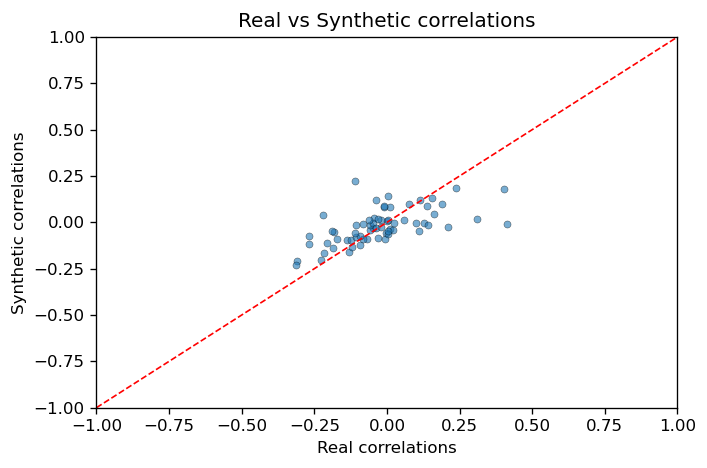

In [71]:
## Using the Pearson correlation matrix to check the correlations between real and the synthetic time series data set

# inputs expected: df_cleaned, ts_24hr_cleaned, feature_cols
assert 'df_cleaned' in globals()
assert 'ts_24hr_cleaned' in globals()
assert 'feature_cols' in globals() and len(feature_cols) > 0

# Correlation matrices (Pearson)
real_corr  = df_cleaned[feature_cols].corr(method='pearson')
synth_corr = ts_24hr_cleaned[feature_cols].corr(method='pearson')

# Flatten upper triangle (unique feature pairs)
mask = np.triu(np.ones(real_corr.shape), k=1).astype(bool)
real_vals  = real_corr.values[mask]
synth_vals = synth_corr.values[mask]

# Pearson similarity between correlation structures
pearson_sim, _ = pearsonr(real_vals, synth_vals)
print(f"Similarity of correlation structures (Pearson): {pearson_sim:.4f}")

# Figure: Scatter real vs synthetic correlations
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(real_vals, synth_vals, alpha=0.6, edgecolor='k', linewidth=0.3, s=18)
plt.plot([-1, 1], [-1, 1], 'r--', linewidth=1)
plt.xlim(-1, 1); plt.ylim(-1, 1)
plt.xlabel("Real correlations")
plt.ylabel("Synthetic correlations")
plt.title("Real vs Synthetic correlations")
plt.tight_layout()
plt.savefig("Scatterplot pearson class together.png", bbox_inches="tight")
plt.show()

In [73]:
## Apply Gaussian copula separately for each label.
# Per-class Gaussian Copulas (sepsis=0/1) and 24h generator 
from scipy.stats import norm

# ECDF helpers
def _ecdf_fit(x):
    x = np.asarray(x, float); x = x[~np.isnan(x)]
    xs = np.sort(x)
    n  = xs.size if xs.size > 0 else 1
    probs = (np.arange(1, n+1) - 0.5) / n
    if xs.size == 0: xs, probs = np.array([0.0]), np.array([1.0])
    return xs, probs

def _to_u(x, xs, probs):  
    return np.interp(x, xs, probs, left=probs[0], right=probs[-1])

def _from_u(u, xs, probs): 
    u = np.clip(u, probs[0], probs[-1])
    return np.interp(u, probs, xs)

# Fit one Gaussian copula block with light shrinkage
def fit_gaussian_copula_block(df_block, feature_cols, alpha=0.05):
    # marginals + latent normals
    marginals = {c: _ecdf_fit(df_block[c].values) for c in feature_cols}
    U = np.column_stack([_to_u(df_block[c].values, *marginals[c]) for c in feature_cols])
    Z = norm.ppf(U); Z[~np.isfinite(Z)] = 0.0

    # empirical correlation
    R = np.corrcoef(Z, rowvar=False)

    # shrink towards identity to stabilize
    p = R.shape[0]
    R = (1 - alpha) * R + alpha * np.eye(p)

    # ensure PD and get Cholesky
    jitter = 0.0
    while True:
        try:
            L = np.linalg.cholesky(R + jitter * np.eye(p))
            break
        except np.linalg.LinAlgError:
            jitter = 1e-8 if jitter == 0 else jitter * 10
            if jitter > 1e-3:
                eigvals, eigvecs = np.linalg.eigh(R)
                eigvals = np.clip(eigvals, 1e-6, None)
                R = eigvecs @ np.diag(eigvals) @ eigvecs.T

    return marginals, L

# Fit per-class copulas on df_cleaned
models_by_label = {}
for lab, sub in df_cleaned.groupby('sepsis_label'):
    sub_block = sub[feature_cols].dropna(how='all')
    if len(sub_block) < 20:  # fallback if too small
        sub_block = df_cleaned[feature_cols]
    models_by_label[int(lab)] = fit_gaussian_copula_block(sub_block, feature_cols, alpha=0.05)

# 24h generator using the matching class model
def gen_24h_per_class(row, rho=0.85):
    label = int(row['sepsis_label'])
    base_time = row['hour']
    patient_id = row['subject_id']

    marginals, L = models_by_label[label]
    p = len(feature_cols); T = 24

    Zt = np.zeros((T, p))
    Zt[0] = np.random.randn(p) @ L.T
    for t in range(1, T):
        eps = np.random.randn(p) @ L.T
        Zt[t] = rho * Zt[t-1] + np.sqrt(1 - rho**2) * eps

    U = norm.cdf(Zt)
    X = np.column_stack([_from_u(U[:, j], *marginals[feature_cols[j]]) for j in range(p)])

    out = pd.DataFrame({
        'subject_id': patient_id,
        'hour': [base_time + pd.Timedelta(hours=i) for i in range(T)],
        'sepsis_label': label
    })
    out = pd.concat([out, pd.DataFrame(X, columns=feature_cols)], axis=1)
    return out

# Build 24h synthetic series for the selected patients
ts_24hr_cleaned = pd.concat(
    [gen_24h_per_class(row) for _, row in selected_patients_cleaned.iterrows()],
    ignore_index=True
).sort_values(['subject_id','hour']).reset_index(drop=True)

# Save
ts_24hr_cleaned.to_csv("synthetic_24hr_patients_perclass.csv", index=False)

In [75]:
ts_24hr_cleaned. shape

(1680, 15)

Similarity of correlation structures (Pearson): 0.8247


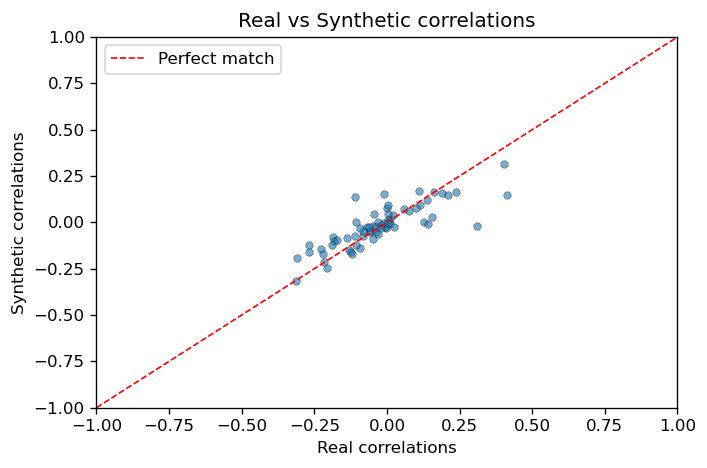

In [77]:
## Using the Pearson correlation matrix to check the correlations between real and the synthetic time series data set
# Correlation matrices  
real_corr  = df_cleaned[feature_cols].corr(method='pearson')
synth_corr = ts_24hr_cleaned[feature_cols].corr(method='pearson')

# Extract upper triangle values (unique feature pairs) 
mask = np.triu(np.ones(real_corr.shape), k=1).astype(bool)
real_vals  = real_corr.values[mask]
synth_vals = synth_corr.values[mask]

# Pearson similarity score
pearson_sim, _ = pearsonr(real_vals, synth_vals)
print(f"Similarity of correlation structures (Pearson): {pearson_sim:.4f}")

# Scatter plot: Real vs Synthetic correlations
plt.figure(figsize=(6,4), dpi=120)
plt.scatter(real_vals, synth_vals, alpha=0.6, edgecolor='k', linewidth=0.3, s=20)
plt.plot([-1, 1], [-1, 1], 'r--', linewidth=1, label="Perfect match")
plt.xlim(-1, 1); plt.ylim(-1, 1)
plt.xlabel("Real correlations")
plt.ylabel("Synthetic correlations")
plt.title("Real vs Synthetic correlations")
plt.legend()
plt.tight_layout()
plt.savefig("Scatterplot pearson perclass.png", bbox_inches="tight")
plt.show()

### 4.2 Applying Gaussian copulas separately for eash labels
(Based on section 4.1, the Gaussian copulas applied to each label separately outperform the Gaussian copulas applied together for the whole data. So, using the application of copulas separately for creating the synthetic time series dataset for the final working dataset.)

In [80]:
# Setup & Copula Fitting (detect numeric features, split by label, fit Gaussian copulas, define sampler)
# Generate Balanced Base Cohort (10k rows - 5000 non-sepsis and 5000 sepsis), assign synthetic IDs & stays, shuffle
# Time-Series Simulation Setup (AR(1) params, label-specific noise, trends, physiological bounds, per-patient scaling)
# Simulate 24-Hour path (drift + AR(1) + noise, clip to bounds, set flags) then build SYN_TS(synthetic timeseries dataset), and save

In [82]:
# Setup & Copula fitting
rng_global = np.random.default_rng(20250909)

#  Setup 
df_static = df_cleaned.copy()

ID_COL, LABEL_COL = 'subject_id', 'sepsis_label'
STAY_COL = 'icustay_id' 

# Numeric feature detection
if 'num_cols' not in globals():
    num_cols = [c for c in df_static.select_dtypes(include=[np.number]).columns
                if c not in {ID_COL, LABEL_COL}]
else:
    num_cols = [c for c in num_cols if pd.api.types.is_numeric_dtype(df_static[c])]

# split by label
g0 = df_static[df_static[LABEL_COL] == 0]
g1 = df_static[df_static[LABEL_COL] == 1]
if len(g0) < 20 or len(g1) < 20:
    warnings.warn("Small group size; copula estimates may be unstable.")

# Gaussian copulas helpers (rank transform, SPD, fitting)
def rank_to_gauss(col: pd.Series) -> pd.Series:
    x = pd.to_numeric(col, errors='coerce')
    n_total = len(x)
    if x.notna().sum() == 0:
        return pd.Series(np.zeros(n_total, dtype=float), index=col.index)
    r = x.rank(method='average', na_option='keep')
    r = r.fillna(r.median())   
    u = (r - 0.5) / n_total
    u = u.clip(1e-6, 1 - 1e-6)
    z = pd.Series(norm.ppf(u), index=col.index)
    return z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

def nearest_spd(A: np.ndarray) -> np.ndarray:
    B = (A + A.T) / 2.0
    w, V = np.linalg.eigh(B)
    w = np.clip(w, 1e-12, None)
    S = (V * w) @ V.T
    return (S + S.T) / 2.0

def fit_copula(group_df: pd.DataFrame, cols):
    Z_df = pd.DataFrame({c: rank_to_gauss(group_df[c]) for c in cols})
    Cov = np.cov(Z_df.values, rowvar=False)
    if np.ndim(Cov) == 0:
        Cov = np.array([[float(Cov)]], dtype=float)
    d = np.sqrt(np.maximum(np.diag(Cov), 1e-12))
    R = Cov / (d[:, None] * d[None, :])
    R = np.nan_to_num(R, nan=0.0)
    np.fill_diagonal(R, 1.0)

    R = nearest_spd(R)
    jitter = 1e-8
    for _ in range(6):
        try:
            L = la.cholesky(R + jitter * np.eye(R.shape[0]), lower=True)
            break
        except Exception:
            jitter *= 10
    else:
        L = np.eye(R.shape[0])

    qgrid = np.linspace(0.001, 0.999, 999)
    inv_cdfs, bounds = {}, {}
    for c in cols:
        x = pd.to_numeric(group_df[c], errors='coerce').dropna().values
        if x.size >= 2:
            inv_cdfs[c] = (qgrid, np.quantile(x, qgrid))
        else:
            inv_cdfs[c] = (qgrid, np.zeros_like(qgrid))
        if x.size >= 10:
            lo, hi = np.quantile(x, [0.01, 0.99])
            pad = 0.1 * (hi - lo + 1e-9)
            bounds[c] = (lo - pad, hi + pad)
        else:
            bounds[c] = (np.nan, np.nan)

    miss = group_df[cols].isna().mean().to_dict()
    return {"L": L, "inv": inv_cdfs, "bounds": bounds, "miss": miss}

# Fit copulas
cop0 = fit_copula(g0, num_cols)
cop1 = fit_copula(g1, num_cols)

# Sampling helpers
def sample_from_copula(n, cop, cols, seed=None):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(size=(n, len(cols))) @ cop["L"].T
    U = norm.cdf(Z)
    X = np.empty_like(U)
    for j, c in enumerate(cols):
        qx, vx = cop["inv"][c]
        X[:, j] = np.interp(U[:, j], qx, vx)
    return pd.DataFrame(X, columns=cols)


In [84]:
#Generate balanced base cohort
#  Balanced 10,000 base rows 
N_SYN = 10_000
n1, n0 = N_SYN // 2, N_SYN - (N_SYN // 2)
B0 = sample_from_copula(n0, cop0, num_cols, seed=123); B0[LABEL_COL] = 0
B1 = sample_from_copula(n1, cop1, num_cols, seed=456); B1[LABEL_COL] = 1
B  = pd.concat([B0, B1], ignore_index=True)

# synthetic IDs and stays
B.insert(0, ID_COL, np.arange(20000, 20000 + len(B)))
B[STAY_COL] = np.arange(20000000, 20000000 + len(B))  # fixed increasing range

# Shuffle to avoid any accidental ordering
B = B.sample(frac=1.0, random_state=4242).reset_index(drop=True)
B[ID_COL] = np.arange(20000, 20000 + len(B))  


In [86]:
# Time series simulation setup
# 24h time-series generator 
phi = 0.80
std0 = g0[num_cols].std(numeric_only=True).reindex(num_cols).fillna(1.0)
std1 = g1[num_cols].std(numeric_only=True).reindex(num_cols).fillna(1.0)
noise_scale0 = (0.30 * std0).replace(0, 0.1)
noise_scale1 = (0.38 * std1).replace(0, 0.1)

# fixed sign trends 
trend_lo = {
    'heart_rate': 0.08,
    'resp_rate': 0.06,
    'map': -0.10,
    'spo2': -0.04,
    'fio2': 0.0025,
    'wbc': 0.018,
    'platelets': -0.45,
    'creatinine': 0.012,
    'bilirubin': 0.010
}
lower_to_actual = {c.lower(): c for c in num_cols}
trend_septic = {lower_to_actual[k]: v for k, v in trend_lo.items() if k in lower_to_actual}
trend_nonsep = {k: v*0.15 for k, v in trend_septic.items()}  # smaller drift for non-sepsis

# physiological limits
PHYS = {
    "FiO2": (0.21, 1.00),
    "PaO2": (30.0, 500.0),
    "MAP": (40.0, 130.0),
    "GCS": (3.0, 15.0),
    "Platelets": (0.0, 1000.0),
    "Bilirubin": (0.0, 20.0),
    "Creatinine": (0.0, 10.0),
    "norepinephrine": (0.0, 1.0),
    "dopamine": (0.0, 20.0),
    "dobutamine": (0.0, 20.0),
}

bounds0, bounds1 = cop0["bounds"], cop1["bounds"]
def clip_bounds(lbl, col, x):
    lo, hi = (bounds1[col] if lbl == 1 else bounds0[col])
    if not np.isnan(lo) and not np.isnan(hi):
        return float(np.clip(x, lo, hi))
    return float(x)

# Patient-specific trend scaling
rows = []
rng = np.random.default_rng(4242)
col_idx = {c: j for j, c in enumerate(num_cols)}
scale_mu, scale_sigma = 0.0, 0.35  
patient_scales = rng.lognormal(mean=scale_mu, sigma=scale_sigma, size=(len(B), len(num_cols)))

In [88]:
# Simulate 24h time series 
for i, r in B.iterrows():
    sid, stay, lab = int(r[ID_COL]), int(r[STAY_COL]), int(r[LABEL_COL])
    x = r[num_cols].values.astype(float)
    base = x.copy()
    noise = (noise_scale1.values if lab == 1 else noise_scale0.values)
    tbase = trend_septic if lab == 1 else trend_nonsep

    # build patient-specific trend vector 
    trend_vec = np.zeros(len(num_cols), dtype=float)
    for c, v in tbase.items():
        j = col_idx.get(c)
        if j is not None:
            trend_vec[j] = v * patient_scales[i, j]

    for h in range(25):
        # deterministic drift
        x = x + trend_vec
        # AR(1) mean-reversion + noise
        x = phi * x + (1 - phi) * base + rng.normal(0.0, noise)
        # empirical group-bounds clip
        for j, c in enumerate(num_cols):
            x[j] = clip_bounds(lab, c, x[j])
        # physiological limits
        for j, c in enumerate(num_cols):
            if c in PHYS:
                lo, hi = PHYS[c]
                x[j] = float(np.clip(x[j], lo, hi))

        rec = {ID_COL: sid, STAY_COL: stay, 'hour': h, LABEL_COL: lab}
        for j, c in enumerate(num_cols):
            rec[c] = float(x[j])
        rec['suspected_infection_flag'] = int(lab == 1 and (h >= 6))
        rows.append(rec)

SYN_TS = pd.DataFrame.from_records(rows)

# Make GCS integer if present
if 'GCS' in SYN_TS.columns:
    SYN_TS['GCS'] = SYN_TS['GCS'].round().clip(3, 15).astype(int)

#  QC, min, max, and save 
print("Patients:", SYN_TS[ID_COL].nunique(), " Rows:")
print("Columns:", SYN_TS.columns.tolist())

# min and max 
pd.set_option("display.float_format", "{:.3f}".format)
desc = SYN_TS.describe().T[['min', 'max']]
print("Min/Max values of synthetic dataset:")
print(desc)

out_path = "Final_Synthetic dataset.csv"
SYN_TS.to_csv(out_path, index=False)

Patients: 10000  Rows:
Columns: ['subject_id', 'icustay_id', 'hour', 'sepsis_label', 'FiO2', 'GCS', 'MAP', 'Bilirubin', 'Creatinine', 'PaO2', 'Platelets', 'dobutamine', 'dopamine', 'norepinephrine', 'suspected_infection_flag']
Min/Max values of synthetic dataset:
                                min        max
subject_id                20000.000  29999.000
icustay_id               304958.236 307814.647
hour                          0.000     24.000
sepsis_label                  0.000      1.000
FiO2                          0.347      1.000
GCS                           3.000     15.000
MAP                          44.809    113.631
Bilirubin                     0.000     20.000
Creatinine                    0.000      6.343
PaO2                         30.000    454.067
Platelets                     0.000    519.967
dobutamine                    0.000      3.442
dopamine                      0.000     11.101
norepinephrine                0.000      0.270
suspected_infection_flag      0